In [1]:
import numpy as np
import sys
from pathlib import Path

Base_Dir = './' # assuming we are in zeldovich-smearing/examples/, else modify this
Like_Dir = Base_Dir + '../code/'
sys.path.append(Like_Dir)

from paths import *
sys.path.append(ML_Path)
from mllib import Utilities

import gc
from time import time

ut = Utilities()

In [2]:
# various matplotlib imports and settings
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

%matplotlib inline  

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 16 # 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# Visualize pairwise correlations in $\texttt{AbacusSummit}$
### Plot various quantities related to $\xi(s,\mu_s)$ and $P(k,\mu_k)$
#### See [$\texttt{AbacusSummit}$](https://abacussummit.readthedocs.io/en/latest/abacussummit.html) for raw data products
***

## Setup

### Files and folders

In [87]:
Plots_Dir = Base_Dir + 'plots/'
Path(Plots_Dir).mkdir(parents=True,exist_ok=True) # folder to store plots

Data_Dir = Base_Dir + 'data/AbacusSummit/base_c000/'

Redshift = 0.8 # 0.1 or 0.8

# don't change default values until alternate data files available
Include_Sig2Obs = False
L_Max = 3
N_Real = 3 # should match what was used
M_min = 8e12 if Redshift > 0.5 else 1.25e13 

File_Stem = 'xi_LMax{0:d}'.format(L_Max)
File_Stem_Real = 'xi'

File_Stem += '_lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift)
File_Stem_Real += '_lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift)

# Xi_File = Data_Dir + File_Stem + '.txt'
Scales_File = Data_Dir + File_Stem + '_scales.txt'
Xi_File_Colwise = Data_Dir + File_Stem + '_colwise.txt'
Xi_Phase_Stem = Data_Dir + File_Stem + '_ph'

if Include_Sig2Obs:
    File_Stem_Sig2Obs = 'Sig2obs'
    File_Stem_Sig2Obs += '_lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift)
    Sig2Obs_File = Data_Dir + File_Stem_Sig2Obs + '.txt'

# Xi_File_Real = Data_Dir + File_Stem_Real + '.txt'
Scales_File_Real = Data_Dir + File_Stem_Real + '_scales.txt'
Xi_File_Colwise_Real = Data_Dir + File_Stem_Real + '_colwise.txt'
Xi_Phase_Stem_Real = Data_Dir + File_Stem_Real + '_ph'

### Read data

In [11]:
print('Reading file: '+Xi_File_Colwise)
xi_cols = np.loadtxt(Xi_File_Colwise).T # expect s|(xi|err)_{ell=0,2,4}
scales = np.loadtxt(Scales_File)
if not np.allclose(xi_cols[0],scales):
    raise Exception('Mismatched scales in file: '+Xi_File_Colwise)
xi = np.zeros((L_Max,scales.size))
err_xi = np.zeros((L_Max,scales.size))
for L in range(L_Max):
    xi[L] = xi_cols[1+2*L]
    err_xi[L] = xi_cols[1+2*L+1]

print('Reading file: '+Xi_File_Colwise_Real)
xi_real = np.loadtxt(Xi_File_Colwise_Real).T # expect s| xi | err
scales_real = np.loadtxt(Scales_File_Real)
if not np.allclose(xi_real[0],scales_real):
    raise Exception('Mismatched scales in file: '+Xi_File_Colwise_Real)
err_xi_real = xi_real[2].copy()
xi_real = xi_real[1].copy()

if Include_Sig2Obs:
    Sig2obs = np.loadtxt(Sig2Obs_File).T # expect ell | Sig2 | err_Sig2
    if not np.allclose(Sig2obs[0],np.array([0,2,4])):
        raise Exception('Mismatched scales in file: '+Sig2Obs_File)
    err_Sig2obs = Sig2obs[2].copy()
    Sig2obs = Sig2obs[1].copy()

Reading file: ./data/AbacusSummit/base_c000/xi_LMax3_lgMmin12.90_z0.800_colwise.txt
Reading file: ./data/AbacusSummit/base_c000/xi_lgMmin12.90_z0.800_colwise.txt


## Plots

In [85]:
Save_Fig = True

Writing to file: ./plots/xi_LMax3_lgMmin12.90_z0.800.pdf


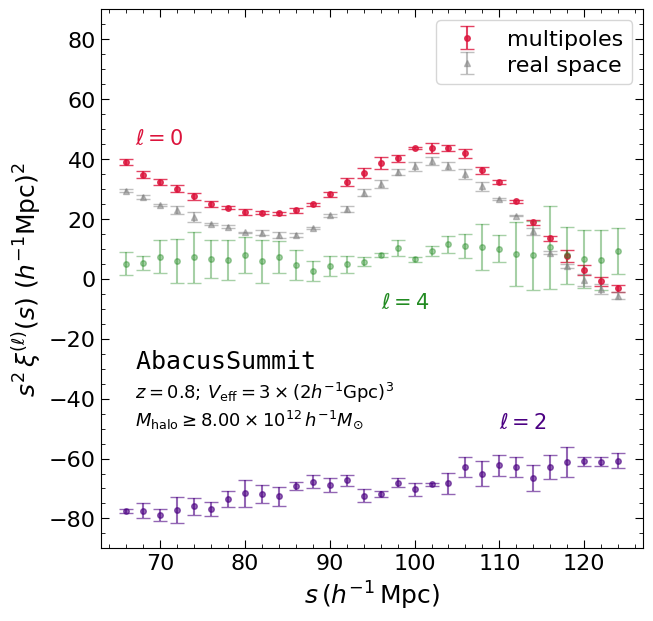

In [90]:
cols = ['crimson','indigo','forestgreen']

plt.figure(figsize=(7,7))
plt.xlabel('$s\\,(h^{{-1}}\\,{{\\rm Mpc}})$')
plt.xlim(63,127)
plt.ylim(-90,90)
ylabel = '$s^{{2}}\\,\\xi^{{(\\ell)}}(s)$'
if Include_Sig2Obs:
    off_vert = 50
    ylabel += '$;\\,\\Sigma^{{(\\ell)2}}+{0:d}$'.format(off_vert)
ylabel += '$\\,\\,(h^{{-1}}{{\\rm Mpc}})^{{2}}$'
plt.ylabel(ylabel)
for L in range(L_Max):
    data_label = 'multipoles' if L==0 else None
    plt.errorbar(scales,scales**2*xi[L],yerr=scales**2*err_xi[L],
                 c=cols[L],ls='none',capsize=5,marker='o',markersize=4,alpha=1-0.2*(L+1),label=data_label)
plt.errorbar(scales_real,scales_real**2*xi_real,yerr=scales_real**2*err_xi_real,
             c='gray',ls='none',capsize=5,marker='^',markersize=4,alpha=0.5,label='real space')

if Include_Sig2Obs:
    Sigx = np.linspace(70,70+5*(L_Max-1),L_Max).astype(int) 
    plt.errorbar(Sigx,Sig2obs+off_vert,yerr=err_Sig2obs,
                 marker='o',ls='none',c='teal',capsize=6,markersize=4,lw=1,alpha=0.6)

plt.text(67,75-105,'$\\tt{{AbacusSummit}}$',fontsize=FS)
zV_text = '$z = {0:.1f}; \\, V_{{\\rm eff}} = {1:d}\\times(2h^{{-1}}{{\\rm Gpc}})^{{3}}$'.format(Redshift,N_Real)
plt.text(67,65-105,zV_text,fontsize=FS3)
mmin_expo = 12.0 if Redshift > 0.5 else 13.0
mmin_absc = M_min/10**mmin_expo
mmin_text = '$M_{{\\rm halo}} \\geq {0:.2f}\\times 10^{{{1:.0f}}}\\, h^{{-1}}M_{{\\odot}}$'.format(mmin_absc,mmin_expo)
plt.text(67,56-105,mmin_text,fontsize=FS3)

plt.text(67,45,'$\ell = 0$',fontsize=FS2,c=cols[0])
if L_Max > 1:
    plt.text(110,-50,'$\ell = 2$',fontsize=FS2,c=cols[1])
    if L_Max == 3:
        plt.text(96,-10,'$\ell = 4$',fontsize=FS2,c=cols[2])

plt.legend(loc='upper right')
plt.minorticks_on()
if Save_Fig:
    Xi_Plot_File = Plots_Dir + File_Stem + '.pdf'
    print('Writing to file: '+Xi_Plot_File)
    plt.savefig(Xi_Plot_File,bbox_inches='tight')
plt.show()
